In [30]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import scipy.stats
from tqdm import tqdm

from sklearn.model_selection import cross_val_predict
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score, mean_squared_error
import itertools

In [31]:
train_adc_info = pd.read_csv('train_adc_info.csv',
                           index_col='planet_id')

In [32]:
# def apply_linear_corr(linear_corr,clean_signal):
#     linear_corr = np.flip(linear_corr, axis=0)
#     for x, y in itertools.product(
#                 range(clean_signal.shape[1]), range(clean_signal.shape[2])
#             ):
#         poli = np.poly1d(linear_corr[:, x, y])
#         clean_signal[:, x, y] = poli(clean_signal[:, x, y])
#     return clean_signal

# def clean_dark(signal, dead, dark, dt):
#     dark = np.ma.masked_where(dead, dark)
#     dark = np.tile(dark, (signal.shape[0], 1, 1))

#     signal -= dark* dt[:, np.newaxis, np.newaxis]
#     return signal

# def preproc(dataset, adc_info, sensor, binning = 15):
#     cut_inf, cut_sup = 39, 321
#     sensor_sizes_dict = {"AIRS-CH0":[[11250, 32, 356], [1, 32, cut_sup-cut_inf]], "FGS1":[[135000, 32, 32], [1, 32, 32]]}
#     binned_dict = {"AIRS-CH0":[11250 // binning // 2, 282], "FGS1":[135000 // binning // 2]}
#     linear_corr_dict = {"AIRS-CH0":(6, 32, 356), "FGS1":(6, 32, 32)}
#     planet_ids = adc_info.index
    
#     feats = []
#     for i, planet_id in tqdm(list(enumerate(planet_ids))):
#         signal = pd.read_parquet(f'/kaggle/input/ariel-data-challenge-2024/{dataset}/{planet_id}/{sensor}_signal.parquet').to_numpy()
#         dark_frame = pd.read_parquet(f'/kaggle/input/ariel-data-challenge-2024/{dataset}/' + str(planet_id) + '/' + sensor + '_calibration/dark.parquet', engine='pyarrow').to_numpy()
#         dead_frame = pd.read_parquet(f'/kaggle/input/ariel-data-challenge-2024/{dataset}/' + str(planet_id) + '/' + sensor + '_calibration/dead.parquet', engine='pyarrow').to_numpy()
#         flat_frame = pd.read_parquet(f'/kaggle/input/ariel-data-challenge-2024/{dataset}/' + str(planet_id) + '/' + sensor + '_calibration/flat.parquet', engine='pyarrow').to_numpy()
#         linear_corr = pd.read_parquet(f'/kaggle/input/ariel-data-challenge-2024/{dataset}/' + str(planet_id) + '/' + sensor + '_calibration/linear_corr.parquet').values.astype(np.float64).reshape(linear_corr_dict[sensor])

#         signal = signal.reshape(sensor_sizes_dict[sensor][0]) 
#         gain = adc_info[f'{sensor}_adc_gain'].values[i]
#         offset = adc_info[f'{sensor}_adc_offset'].values[i]
#         signal = signal / gain + offset
        
#         if sensor != "FGS1":
#             signal = signal[:, :, cut_inf:cut_sup] #11250 * 32 * 282
#             dt = axis_info['AIRS-CH0-integration_time'].dropna().values
#             linear_corr = linear_corr[:, :, cut_inf:cut_sup]
#             dark_frame = dark_frame[:, cut_inf:cut_sup]
#             dead_frame = dead_frame[:, cut_inf:cut_sup]
#             flat_frame = flat_frame[:, cut_inf:cut_sup]
#         else:
#             dt = np.ones(len(signal))*0.1 
            
#         linear_corr_signal = apply_linear_corr(linear_corr, signal)
#         signal = clean_dark(signal, dark_frame, dark_frame, dt)
        
#         flat = flat_frame.reshape(sensor_sizes_dict[sensor][1])
#         flat[dead_frame.reshape(sensor_sizes_dict[sensor][1])] = np.nan
#         signal = signal / flat
        
#         if sensor == "FGS1":
#             signal = signal.reshape((sensor_sizes_dict[sensor][0][0], sensor_sizes_dict[sensor][0][1]*sensor_sizes_dict[sensor][0][2]))
        
#         mean_signal = np.nanmean(signal, axis=1) # mean over the 32*32(FGS1) or 32(CH0) pixels
#         cds_signal = (mean_signal[1::2] - mean_signal[0::2])
#         binned = np.zeros((binned_dict[sensor]))
#         for j in range(cds_signal.shape[0] // binning):
#             binned[j] = cds_signal[j*binning:j*binning+binning].mean(axis=0)
                   
#         if sensor == "FGS1":
#             binned = binned.reshape((binned.shape[0],1))
            
#         feats.append(binned)
        
#     return np.stack(feats)
    
# pre_train = np.concatenate([preproc('train', train_adc_info, "FGS1", 15*12), preproc('train', train_adc_info, "AIRS-CH0", 15)], axis=2)

In [33]:
# np.save("data_pretrain.npy", pre_train)

In [34]:
# pre_train.shape

In [35]:
# np.save('/kaggle/working/' + 'data_pretrain_clean.npy', pre_train)

In [36]:
# def phase_detector(signal):
#     phase1, phase2 = None, None
#     best_drop = 0
#     for i in range(50,150):        
#         t1 = signal[i:i+20].max() - signal[i:i+20].min()
#         if t1 > best_drop:
#             phase1 = i+20+5
#             best_drop = t1
    
#     best_drop = 0
#     for i in range(200,300):
#         t1 = signal[i:i+20].max() - signal[i:i+20].min()
#         if t1 > best_drop:
#             phase2 = i-5
#             best_drop = t1
    
#     return phase1, phase2

# train = pre_train.copy()
# for i in range(len(train_adc_info)):
    
#     p1,p2 = phase_detector(pre_train[i,:,1:].mean(axis=1))
#     train[i] = (train[i] - pre_train[i,p1:p2].mean(axis=0)) / pre_train[i,list(range(p1-40)) + list(range(p2+40,375))].mean(axis=0) * 1000.0

In [37]:
# np.save('/kaggle/working/' + 'data_train_clean.npy', train)

In [38]:
# pre_train[i,:,1:].mean(axis=1).shapex

In [39]:
# pre_train.shape

In [40]:
train = np.load('data_train_clean.npy')

In [41]:
train_adc_info.index

Int64Index([    785834,   14485303,   17002355,   24135240,   25070640,
              26372015,   29348276,   33548644,   50637799,   53735941,
            ...
            4205863992, 4228013544, 4246618328, 4247255382, 4247918843,
            4249337798, 4257395405, 4266129805, 4273166473, 4286133832],
           dtype='int64', name='planet_id', length=673)

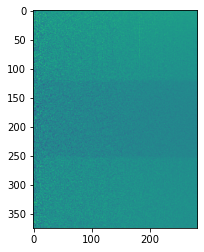

In [42]:
plt.imshow(train[0])

In [44]:
import torch
from torch.utils.data import Dataset, DataLoader
import pandas as pd
import numpy as np
import os

class CustomDataset(Dataset):
    def __init__(self, data_train, indices, path_labels):
        """
        Args:
            data_train (np.array): Array of shape (673, 187, 282, 32).
            indices (np.array): Array of indices corresponding to the rows in df_labels.
            path_labels (str): Path to the CSV file containing labels.
        """
        self.data_train = torch.tensor(data_train)  # Convert the data to a tensor
        self.data_indices = torch.tensor(indices).long()  # Convert indices to tensor
        self.df_labels = pd.read_csv(path_labels)  # Load df_labels as a pandas DataFrame
        
    def __len__(self):
        # Return the total number of samples
        return len(self.data_indices)

    def __getitem__(self, idx):
        # Get the index from data_indices
        index = self.data_indices[idx].item()  # Convert tensor to Python scalar
        
        # Select the data_train sample corresponding to the index
        data_sample = self.data_train[idx]  # Directly access the data without cloning

        # Select the corresponding label row where the first column matches the index
        label_row = self.df_labels[self.df_labels.iloc[:, 0] == index].iloc[0].values[1:]  # Exclude the first column (index)

        # Convert label_row to a tensor
        label = torch.tensor(label_row).float()

        return data_sample, label

# Example usage
path_ground = 'train_labels.csv'

# Assuming 'train' and 'train_adc_info' are pre-loaded variables containing the training data and indices.
# For example, train could be an array of shape (673, 187, 282, 32), and train_adc_info.index gives the indices.
custom_dataset = CustomDataset(train, train_adc_info.index, path_ground)

# Create a DataLoader to iterate over the dataset
dataloader = DataLoader(custom_dataset, batch_size=32, shuffle=True)  # Pass 'custom_dataset' here

# Iterate through the dataset
for batch_data, batch_labels in dataloader:
    print("Batch Data Shape:", batch_data.shape)  # Should be (batch_size, 187, 282, 32)
    print("Batch Labels Shape:", batch_labels.shape)  # Should be (batch_size, 283)
    break


Batch Data Shape: torch.Size([32, 375, 283])
Batch Labels Shape: torch.Size([32, 283])


In [45]:
import torchvision.models as models

In [46]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class SpectralConv(nn.Module):
    def __init__(self):
        super(SpectralConv, self).__init__()
        
        self.model = models.resnet50(pretrained=True)
        self.model.conv1 = nn.Conv2d(1, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
        self.model.fc = nn.Linear(in_features=2048, out_features=283*2, bias=True)

    
    def forward(self, x):
        # Apply convolutional layer
        x = self.model(x)
        
        # Apply a Sigmoid activation after conv1
        x = torch.sigmoid(x)
        
        return x

# Example usage:
model = SpectralConv()
model


/Users/aditya/opt/anaconda3/lib/python3.9/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/Users/aditya/opt/anaconda3/lib/python3.9/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


SpectralConv(
  (model): ResNet(
    (conv1): Conv2d(1, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (downsample): Sequential(
       

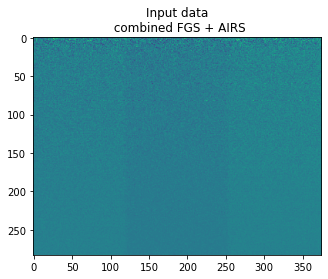

In [47]:
plt.imshow(batch_data[0,:,:].T)
plt.title('Input data\n combined FGS + AIRS')
plt.show()

/var/folders/dp/l6p51q511nbb1spwhbnzhnkc0000gs/T/ipykernel_4776/2867722626.py:1: UserWarning: The use of `x.T` on tensors of dimension other than 2 to reverse their shape is deprecated and it will throw an error in a future release. Consider `x.mT` to transpose batches of matrices or `x.permute(*torch.arange(x.ndim - 1, -1, -1))` to reverse the dimensions of a tensor. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/native/TensorShape.cpp:3641.)
  plt.plot(batch_labels[-1].T)


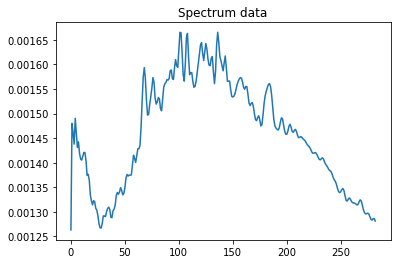

In [48]:
plt.plot(batch_labels[-1].T)
plt.title("Spectrum data")
plt.show()

In [61]:
args = {}

# Training params

args['batch_size'] = 32
args['test_batch_size'] = 10

args['epochs'] = 50*10
args['start_epoch'] = 0




# For optimizer
args['lr'] = 1e-5 # LR for B-SNN params
args['lr_decay'] = 1e-6
args['warmup_epochs'] = 10
args['lr_start'] = 1e-5


args['momentum'] = 0.5 # Required for SGD optimiser
args['weight_decay'] = 1e-4 # Weight-decay for ADAM-W optimiser



args['device'] =  torch.device('mps' if torch.backends.mps.is_available() else 'cpu')


In [62]:
import torch
import torch.nn as nn

class ParticipantVisibleError(Exception):
    pass

class ArielLoss(nn.Module):
    def __init__(self, naive_mean, naive_sigma, sigma_true):
        super(ArielLoss, self).__init__()
        self.naive_mean = naive_mean
        self.naive_sigma = naive_sigma
        self.sigma_true = sigma_true

    def forward(self, solution, submission):
        '''
        This is a Gaussian Log Likelihood based loss function. For a submission, which contains the predicted mean (x_hat) and variance (x_hat_std),
        we calculate the Gaussian Log-likelihood (GLL) value compared to the provided ground truth (x). We treat each pair of x_hat,
        x_hat_std as a 1D gaussian, meaning there will be 283 1D gaussian distributions, hence 283 values for each test spectrum,
        the GLL value for one spectrum is the sum of all of them.

        Inputs:
            - solution: Ground Truth spectra (from test set)
                - shape: (nsamples, n_wavelengths)
            - submission: Predicted spectra and errors (from participants)
                - shape: (nsamples, n_wavelengths*2)
        '''
        if torch.any(submission < 0):
            raise ParticipantVisibleError('Negative values in the submission')

        n_wavelengths = 283

        # Predicted mean and standard deviation
        y_pred = submission[:, :n_wavelengths]
        # Set a non-zero minimum sigma pred to prevent division by zero errors
        sigma_pred = torch.clamp(submission[:, n_wavelengths:], min=1e-15)
        y_true = solution

        # Gaussian log-likelihood calculations
        GLL_pred = torch.sum(-0.5 * ((y_true - y_pred) / sigma_pred)**2 - torch.log(sigma_pred) - 0.5 * torch.log(torch.tensor(2 * torch.pi)))
        GLL_true = torch.sum(-0.5 * ((y_true - y_true) / (self.sigma_true * torch.ones_like(y_true)))**2 - torch.log(self.sigma_true * torch.ones_like(y_true)) - 0.5 * torch.log(torch.tensor(2 * torch.pi)))
        GLL_mean = torch.sum(-0.5 * ((y_true - self.naive_mean * torch.ones_like(y_true)) / (self.naive_sigma * torch.ones_like(y_true)))**2 - torch.log(self.naive_sigma * torch.ones_like(y_true)) - 0.5 * torch.log(torch.tensor(2 * torch.pi)))

        # Score calculation
        submit_score = (GLL_pred - GLL_mean) / (GLL_true - GLL_mean)
        # submit_score = torch.clamp(submit_score, 0.0, 1.0)

        return -submit_score  # Return negative score as loss (since lower loss is better for training)


In [63]:
naive_mean = 0
naive_std = 0
count = 0

for train_batch_idx, (img, y_true) in enumerate(dataloader):

    naive_mean += y_true.mean()
    naive_std += y_true.std()

    count += 1

print('Naive Mean: {}'.format(naive_mean/count))
print('Naive std: {}'.format(naive_std/count))
    

Naive Mean: 0.0024828987661749125
Naive std: 0.0016191874165087938


In [64]:
import time

In [65]:
import torch
import torch.optim as optim



# Assuming SpectralTransformer and GLLLoss are already defined
specTrans = SpectralConv()
specTrans.to(args['device'])


# Optimizer with a smaller learning rate
optimizer = optim.Adam(specTrans.parameters(), lr=args['lr'], betas=(0.9, 0.999), eps=1e-08)

# Use the custom lr scheduler

# criterion =  nn.MSELoss()
# Use the custom lr scheduler

# Quantile loss for two quantiles: 0.1 and 0.9
# quantile_loss_fn = QuantileLoss(quantiles=[0.1, 0.9])

# Training loop
start_time = time.time()

loss_train_arr = []
loss_valid_arr = []

loss_min = np.inf
acc_max = -np.inf


for epoch in range(args['start_epoch'], args['epochs']):
    specTrans.train()

    # Calculate the current learning rate
    # current_lr = lrfn(epoch, num_warmup_steps=N_WARMUP_EPOCHS, lr_max=LR_MAX, num_cycles=0.50)
    #lrfn(current_step, num_warmup_steps, lr_max, num_cycles=0.50, num_training_steps=N_EPOCHS)

    train_acc = 0
    val_acc = 0
    loss_train = 0
    loss_valid = 0
    train_samples = 0
    val_samples = 0
    running_train_loss = 0
    running_eval_loss = 0


        
    for train_batch_idx, (img, y_true) in enumerate(dataloader):

        # Clear gradients for the optimizer before backward pass
        optimizer.zero_grad()
        
        

        img = img.to(torch.float32).to(args['device'])
        y_true = y_true.to(torch.float32).to(args['device'])
    
        # Forward pass
        y_pred = specTrans(img.unsqueeze(1)) # 283 dimensional
        # print(y_pred.isnan())
        # outputs = y_pred.view(-1, 283, 2)  # Reshape to (batch_size, time_steps, 283 features, 2 quantiles)
        
        train_loss_step = ArielLoss(naive_mean=naive_mean, naive_sigma=naive_std, sigma_true=1e-5)(        
            y_true,
            y_pred)
        
        # Compute loss
        # train_loss_step = quantile_loss_fn(outputs, y_true)

        # train_loss_step = torch.norm(y_true - y_pred, 1)/y_true.shape[0]#criterion(y_pred, y_true) #torch.norm(y_true - y_pred, 1)/y_true.shape[0]

        # Backward pass on the loss, not the score
        train_loss_step.backward()


        # Update the weights
        optimizer.step()
    
        print("Train loss: {}".format(float(train_loss_step)))

        # # If you want to accumulate training loss across the epoch
       
        lr_th_print = optimizer.param_groups[0]["lr"]
        print("LR: {:9f}".format(lr_th_print))

    # Print the accumulated loss per epoch (optional)
    print(f'Epoch {epoch} finished')

    if epoch % 20 == 0:

        chckpt_file_path = 'checkpoint_submission_resnet_{}.pth'.format(epoch)
        torch.save(specTrans.state_dict(), chckpt_file_path)

    # You can also save checkpoints and track validation loss/accuracy here if needed

end_time = time.time()
print('Total training time: {:.4f} seconds'.format(end_time - start_time))


Train loss: 0.22821222245693207
LR:  0.000010
Train loss: 0.2284177988767624
LR:  0.000010
Train loss: 0.22867324948310852
LR:  0.000010
Train loss: 0.22305984795093536
LR:  0.000010
Train loss: 0.22474521398544312
LR:  0.000010
Train loss: 0.22372229397296906
LR:  0.000010
Train loss: 0.2257673293352127
LR:  0.000010
Train loss: 0.22179660201072693
LR:  0.000010
Train loss: 0.22205190360546112
LR:  0.000010
Train loss: 0.22339114546775818
LR:  0.000010
Train loss: 0.21996399760246277
LR:  0.000010
Train loss: 0.22354573011398315
LR:  0.000010
Train loss: 0.22116988897323608
LR:  0.000010
Train loss: 0.22070853412151337
LR:  0.000010
Train loss: 0.22007006406784058
LR:  0.000010
Train loss: 0.21935901045799255
LR:  0.000010
Train loss: 0.220464289188385
LR:  0.000010
Train loss: 0.21733781695365906
LR:  0.000010
Train loss: 0.21747586131095886
LR:  0.000010
Train loss: 0.21767210960388184
LR:  0.000010
Train loss: 0.21336397528648376
LR:  0.000010
Train loss: 0.2085503488779068
LR:  0.